# Factor risk allocation: what does the capital really own?

[Chapter](README.md) · [Allocation ideas](../../README.md)

Four equally funded assets can still share one dominant source of risk. In this constructed model, the growth factor accounts for **93.1% of equal-weight portfolio variance**. A fixed exposure policy reduces that share to **48.8%**, while placing **50% of capital in one duration asset**. Economic risk diversification and asset-weight diversification answer different questions.

This is an original, deterministic allocation experiment, not a market backtest. The decision is to implement specified factor exposures with the least residual variance under a 65% asset cap. It does not estimate expected return, optimize a Sharpe ratio, or claim that these are optimal investor exposures.

## Specify economic exposures before optimizing weights

Use annual excess-return units and the model $r=Bf+\epsilon$, with $\operatorname{Cov}(f,\epsilon)=0$ and $\Sigma=BFB^\top+D$. The factors are constructed **growth-sensitive and duration return proxies**, not GDP growth and a yield change. Their labels express an economic interpretation that would need validation in real data.

Factor volatilities are 16% and 7%; their correlation is −0.25. Residual volatilities are 5%, 4%, 3.5% and 1.5%, with independent residuals. All loadings and risk parameters are assumed known. The desired exposures $(0.40,0.90)$ and 65% cap are fixed policy assumptions, not fitted outputs.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "research/factors_liabilities.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from research.factors_liabilities import (
    factor_decomposition, exposure_target_allocation,
    cashflow_measures, match_liability_zeros,
)
plt.rcParams.update({"figure.figsize": (10, 4), "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.18,
                     "axes.axisbelow": True})
BLUE, GOLD, ORANGE, GREY = "#245B83", "#B78324", "#BB623B", "#69747E"
assets = ["Equity A", "Equity B", "Credit", "Duration"]
factors = ["Growth", "Duration"]
B = np.array([[1.05, .15], [.95, .25], [.65, .55], [.10, 1.30]])
factor_vol = np.array([.16, .07])
F = np.outer(factor_vol, factor_vol) * np.array([[1, -.25], [-.25, 1]])
D = np.diag(np.array([.05, .04, .035, .015]) ** 2)
policy_target = np.array([.40, .90])
display(pd.DataFrame(B, index=assets, columns=["Growth loading", "Duration loading"]).round(3))


,Growth loading,Duration loading
Equity A,1.05,0.15
Equity B,0.95,0.25
Credit,0.65,0.55
Duration,0.10,1.30


## Translate the policy into funded asset weights

Solve $\min_w w^\top Dw$ subject to $B^\top w=z^*$, $\mathbf1^\top w=1$ and $0\le w_i\le0.65$. Once exposures are fixed, $z^{*\top}Fz^*$ is constant; minimizing residual variance also minimizes total variance **within that exposure set**. This is exact exposure targeting, not equal factor risk contribution. An infeasible policy raises an error instead of silently changing the target.

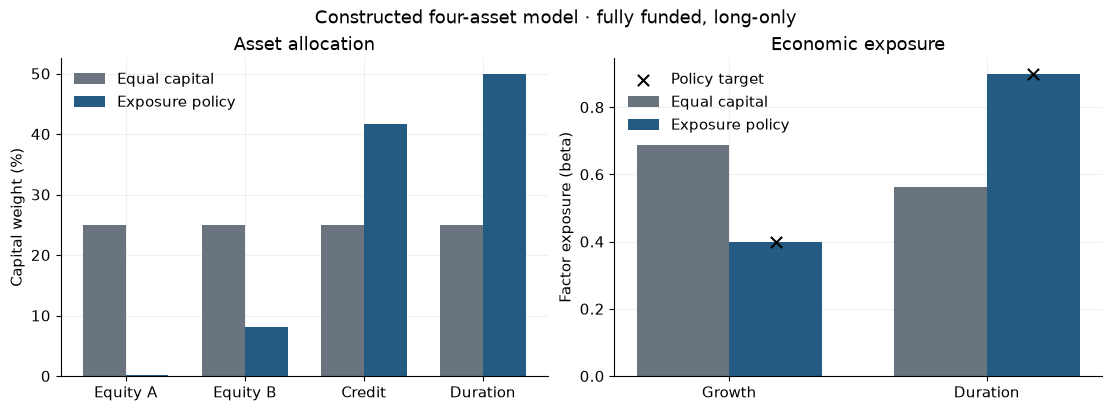

In [2]:
weights = {
    "Equal capital": np.full(4, .25),
    "Exposure policy": exposure_target_allocation(B, D, policy_target, cap=.65),
}
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
x = np.arange(4)
for offset, (name, w), color in zip([-.18, .18], weights.items(), [GREY, BLUE]):
    axes[0].bar(x + offset, 100*w, .36, label=name, color=color)
axes[0].set(xticks=x, xticklabels=assets, ylabel="Capital weight (%)", title="Asset allocation")
axes[0].legend(frameon=False)
y = np.arange(2)
for offset, (name, w), color in zip([-.18, .18], weights.items(), [GREY, BLUE]):
    axes[1].bar(y + offset, B.T @ w, .36, label=name, color=color)
axes[1].scatter(y + .18, policy_target, marker="x", color="black", s=65, label="Policy target", zorder=4)
axes[1].set(xticks=y, xticklabels=factors, ylabel="Factor exposure (beta)", title="Economic exposure")
axes[1].legend(frameon=False)
fig.suptitle("Constructed four-asset model · fully funded, long-only")
plt.show()


The policy holds 41.7% Credit and 50.0% Duration. Its concentration in two assets is visible rather than hidden by a factor label. These assets are the available instruments for the desired exposures; broadening their number without changing their economic risks would not create new independent return drivers.

## Attribute variance without deleting the covariance terms

Write $z=B^\top w$. Each factor's signed variance contribution is $c_j=z_j(Fz)_j$; residual variance is $w^\top Dw$. The factor components plus the residual equal $w^\top\Sigma w$. Each pairwise covariance term is shared between its two factors. These are additive **variance** contributions; taking the square root of each and adding would be incorrect. With correlated factors, a hedging component can be negative, and attribution depends on the factor basis.

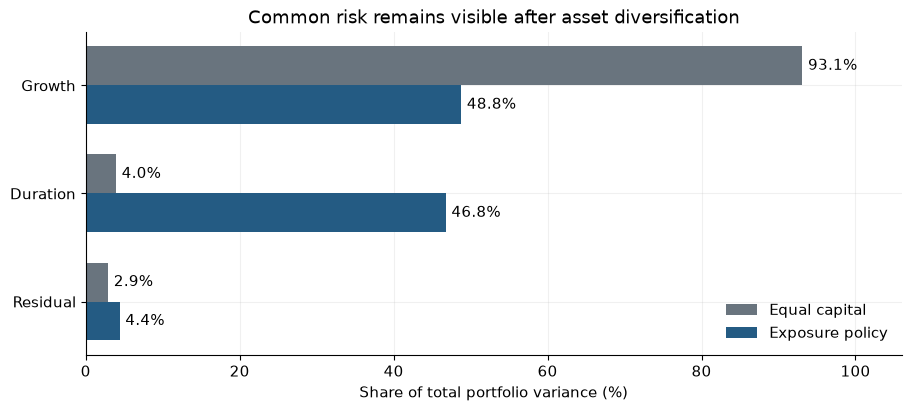

,Annual volatility (%),Largest asset weight (%)
Equal capital,10.88,25.0
Exposure policy,7.96,50.0


In [3]:
decompositions = {name: factor_decomposition(w, B, F, D) for name, w in weights.items()}
shares = pd.DataFrame({name: np.r_[d["factor_variance"], d["residual_variance"]] / d["variance"]
                       for name, d in decompositions.items()}, index=["Growth", "Duration", "Residual"])
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
y = np.arange(3)
for offset, name, color in zip([-.18, .18], weights, [GREY, BLUE]):
    values = 100 * shares[name].to_numpy()
    bars = ax.barh(y + offset, values, .36, color=color, label=name)
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in values], padding=4)
ax.set(yticks=y, yticklabels=shares.index, xlabel="Share of total portfolio variance (%)",
       title="Common risk remains visible after asset diversification", xlim=(0, 106))
ax.invert_yaxis()
ax.legend(frameon=False, loc="lower right")
plt.show()
display(pd.DataFrame({name: {"Annual volatility (%)": 100*np.sqrt(d["variance"]),
                            "Largest asset weight (%)": 100*weights[name].max()}
                      for name, d in decompositions.items()}).T.round(2))


At the assumed covariance, the policy distributes 48.8%, 46.8% and 4.4% of total variance to Growth, Duration and residual risk. The near balance is a consequence of these chosen exposures and risk inputs; the optimizer did not solve a risk-budgeting objective. Its 7.96% annual volatility versus 10.88% for equal capital is model risk, not observed performance or a matched-risk comparison.

## Freeze the weights and challenge the factor model

The two alternatives below are declared model stresses: factor correlation rises from −0.25 to +0.50, or Credit/Duration growth loadings increase to 1.10/0.30. Each changes one modeling dimension while keeping portfolio weights fixed. They are deterministic scenarios, not probability or confidence intervals.

In [4]:
stress_F = np.outer(factor_vol, factor_vol) * np.array([[1, .50], [.50, 1]])
stress_B = B.copy()
stress_B[2:, 0] = [1.10, .30]
rows = []
for scenario, b, f in [("Declared base", B, F), ("Correlation +0.50", B, stress_F),
                       ("Growth-loading shift", stress_B, F)]:
    for name, w in weights.items():
        d = factor_decomposition(w, b, f, D)
        rows.append([scenario, name, *d["exposures"], 100*np.sqrt(d["variance"])])
display(pd.DataFrame(rows, columns=["Scenario", "Policy", "Growth exposure", "Duration exposure",
                                   "Annual volatility (%)"]).round(3))


,Scenario,Policy,Growth exposure,Duration exposure,Annual volatility (%)
0,Declared base,Equal capital,0.688,0.562,10.877
1,Declared base,Exposure policy,0.400,0.900,7.956
2,Correlation +0.50,Equal capital,0.688,0.562,13.538
3,Correlation +0.50,Exposure policy,0.400,0.900,11.125
4,Growth-loading shift,Equal capital,0.850,0.562,13.310
5,Growth-loading shift,Exposure policy,0.688,0.900,11.354


The exact exposure constraints hold only in the declared base model. Growth loading error changes the economic policy even though no capital is traded; correlation stress changes risk contributions while leaving betas unchanged. A low-dimensional factor model can reduce estimation burden, but choosing factors after inspecting attractive backtests creates another selection problem. In a real study, exposures, shrinkage settings and rebalance rules must be estimated inside the training window and evaluated under costs and factor-definition changes.

## Reconcile with independent calculations and a known solution

In [5]:
# Direct asset covariance reconstruction checks the complete variance budget.
Sigma = B @ F @ B.T + D
for name, w in weights.items():
    np.testing.assert_allclose(decompositions[name]["variance"], w @ Sigma @ w, atol=1e-14)
np.testing.assert_allclose(B.T @ weights["Exposure policy"], policy_target, atol=1e-9)
# Two assets with identical growth exposure split 60% inversely to residual variances 1 and 4.
small_B = np.array([[1., 0], [1., 0], [0, 1.]])
known = exposure_target_allocation(small_B, np.diag([1., 4., 2.]), [.6, .4])
np.testing.assert_allclose(known, [.48, .12, .40], atol=1e-7)
# Correlation can create a negative contribution. Preserve it and the total.
hedging = factor_decomposition([1., .1], np.eye(2), [[1., -.9], [-.9, 1.]], np.zeros((2, 2)))
np.testing.assert_allclose(hedging["factor_variance"], [.91, -.08], atol=1e-14)
assert np.isclose(hedging["variance"], .83)
print("Independent covariance, analytic allocation and signed-risk checks passed.")


Independent covariance, analytic allocation and signed-risk checks passed.


## Check an impossible exposure request

In [6]:
try:
    exposure_target_allocation(B, D, [.0, .0], cap=.65)
except ValueError as exc:
    print(f"Infeasible request rejected: {exc}")
else:
    raise AssertionError("A long-only zero-exposure portfolio should not exist here")


Infeasible request rejected: Target exposures are infeasible under the allocation constraints


## Take the idea further

The useful question is whether the chosen factor exposures match the portfolio's economic purpose, not whether the factor labels sound diversified. An implementable extension would fit exposures from point-in-time return proxies, report residual correlations, account for instrument turnover and compare several fixed economic stress sets. No such empirical extension is claimed here.

[Sharpe (2001)](https://web.stanford.edu/~wfsharpe/art/q2001/q2001.htm) develops pension risk budgeting with factor models and liabilities. [Israel and Ross's practical guide](https://images.aqr.com/-/media/AQR/Documents/Insights/Trade-Publications/Measuring-Portfolio-Factor-Exposures-A-Practical-Guide.pdf) explains why factor definitions and implementation affect measured exposures. The inputs, optimization example, tests and figures here are original. See also [asset risk parity](../02-risk-parity/README.md) and [estimation risk](../12-estimation-risk/README.md).